In [ ]:

..import torch
import captum
import numpy as np

print("Torch:", torch.__version__)
print("Captum:", captum.__version__)
print("Numpy:", np.__version__)

Torch: 2.10.0+cpu
Captum: 0.8.0
Numpy: 1.26.4


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

from captum.attr import LayerGradCam, LayerAttribution

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Step 1: Define model
model = models.efficientnet_b3(weights=None)

# IMPORTANT: classification → 2 outputs
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

# Step 2: Load state_dict
state_dict = torch.load(
    "/content/drive/MyDrive/REFUGE2_RESULTS/MODEL15_EfficientNetB3.pth",
    map_location=DEVICE
)

# Step 3: FIX PREFIX ISSUE (VERY IMPORTANT)
new_state_dict = {}

for k, v in state_dict.items():
    # remove "backbone." if exists
    if k.startswith("backbone."):
        new_key = k.replace("backbone.", "")
    else:
        new_key = k
    new_state_dict[new_key] = v

# Step 4: Remove classifier mismatch (safety)
filtered_state_dict = {
    k: v for k, v in new_state_dict.items()
    if "classifier" not in k
}

# Step 5: Load weights
model.load_state_dict(filtered_state_dict, strict=False)

# Step 6: Final setup
model.to(DEVICE)
model.eval()

print("Model loaded successfully ")

Model loaded successfully 


In [ ]:
target_layer = model.features[-1][0]

In [ ]:
from captum.attr import LayerGradCam, LayerAttribution

target_layer = model.features[-1][0]
gradcam = LayerGradCam(model, target_layer)

In [ ]:
from PIL import Image
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

img_path = "/content/drive/MyDrive/REFUGE2/test/images/T0001.jpg"

image = Image.open(img_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(DEVICE)

In [ ]:
output = model(input_tensor)
pred_class = torch.argmax(output, dim=1).item()

print("Predicted class:", pred_class)

Predicted class: 1


In [ ]:
attribution = gradcam.attribute(input_tensor, target=pred_class)
attribution = LayerAttribution.interpolate(attribution, (224, 224))

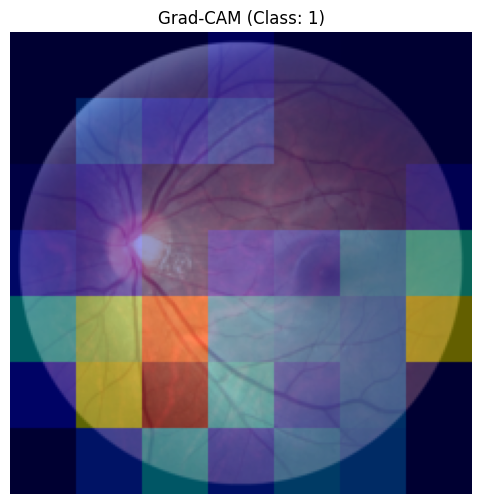

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert attribution
attr = attribution.squeeze().cpu().detach().numpy()

# Normalize
attr = np.maximum(attr, 0)
attr = attr / (attr.max() + 1e-8)

# Original image
img_np = input_tensor.squeeze().permute(1,2,0).cpu().numpy()

# Plot
plt.figure(figsize=(6,6))
plt.imshow(img_np)
plt.imshow(attr, cmap='jet', alpha=0.4)
plt.title(f"Grad-CAM (Class: {pred_class})")
plt.axis('off')
plt.show()

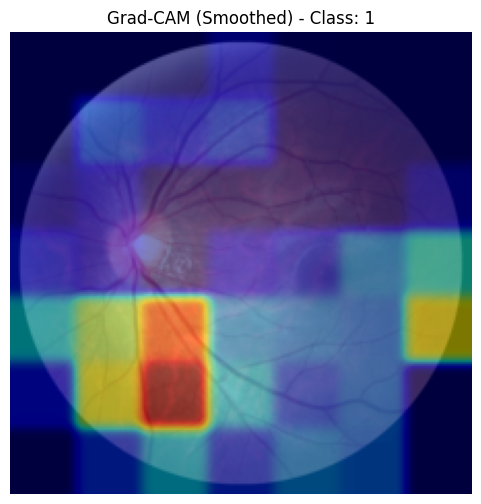

In [ ]:
import cv2

# Convert attribution
attr = attribution.squeeze().cpu().detach().numpy()

# Normalize
attr = np.maximum(attr, 0)
attr = attr / (attr.max() + 1e-8)

# Resize smoothly using OpenCV
attr = cv2.resize(attr, (224, 224))

# Apply Gaussian blur (smoothens blocks)
attr = cv2.GaussianBlur(attr, (15, 15), 0)

# Original image
img_np = input_tensor.squeeze().permute(1,2,0).cpu().numpy()

# Plot
plt.figure(figsize=(6,6))
plt.imshow(img_np)
plt.imshow(attr, cmap='jet', alpha=0.5)
plt.title(f"Grad-CAM (Smoothed) - Class: {pred_class}")
plt.axis('off')
plt.show()

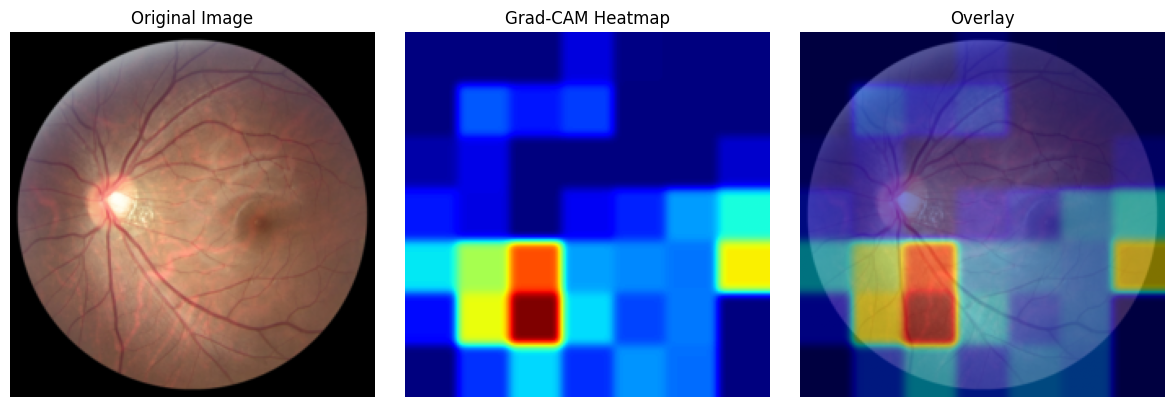

In [ ]:
import cv2

# Prepare heatmap
attr = attribution.squeeze().cpu().detach().numpy()
attr = np.maximum(attr, 0)
attr = attr / (attr.max() + 1e-8)

attr = cv2.resize(attr, (224, 224))
attr = cv2.GaussianBlur(attr, (15, 15), 0)

# Original image
img_np = input_tensor.squeeze().permute(1,2,0).cpu().numpy()

# Heatmap color
heatmap = cv2.applyColorMap(np.uint8(255 * attr), cv2.COLORMAP_JET)
heatmap = heatmap[..., ::-1] / 255.0  # BGR → RGB

# Overlay
overlay = heatmap * 0.5 + img_np * 0.5

# Plot
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_np)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(attr, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Overlay")
plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
print("Insight: Model focuses on optic disc region for glaucoma detection")

Insight: Model focuses on optic disc region for glaucoma detection


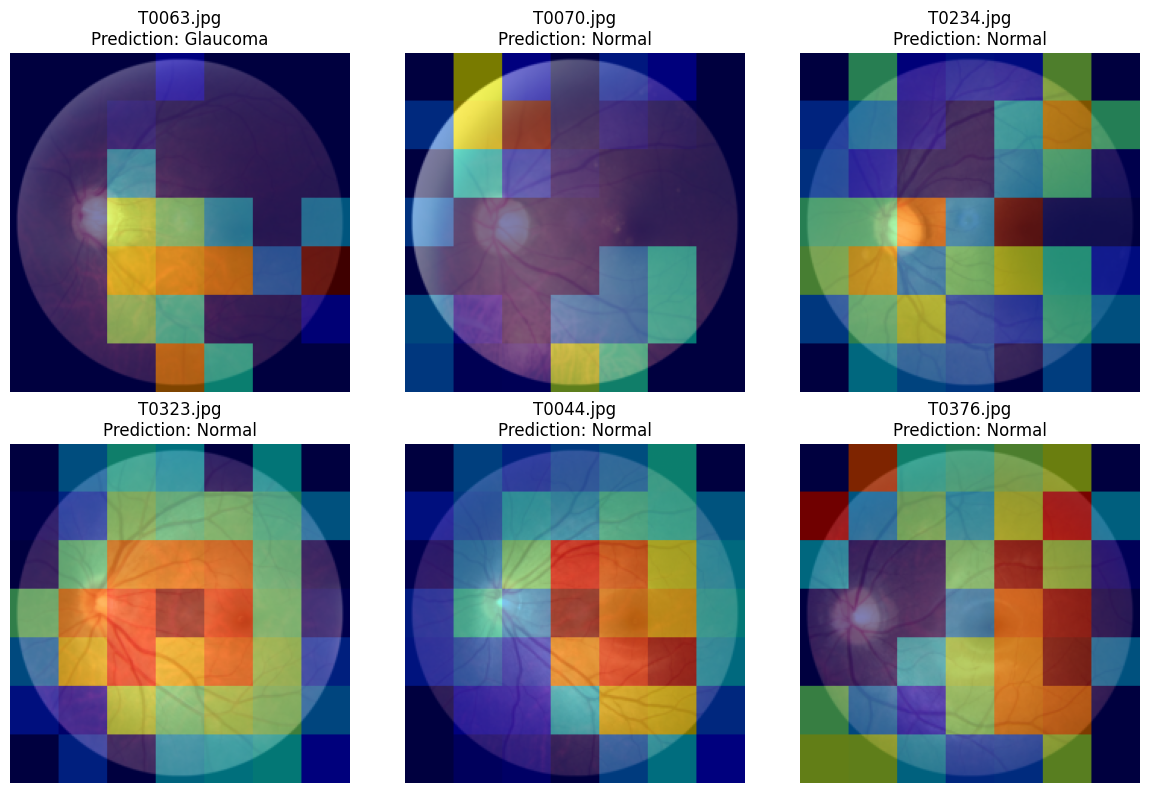

In [ ]:
import os
import random
test_dir = "/content/drive/MyDrive/REFUGE2/test/images"
images = random.sample(os.listdir(test_dir), 6)

plt.figure(figsize=(12,8))

for i, img_name in enumerate(images):
    img_path = os.path.join(test_dir, img_name)

    image = Image.open(img_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(DEVICE)

    output = model(input_tensor)
    pred_class = torch.argmax(output, dim=1).item()

    attr = gradcam.attribute(input_tensor, target=pred_class)
    attr = LayerAttribution.interpolate(attr, (224, 224))

    attr = attr.squeeze().cpu().detach().numpy()
    attr = np.maximum(attr, 0)
    attr = attr / (attr.max() + 1e-8)

    img_np = input_tensor.squeeze().permute(1,2,0).cpu().numpy()

    plt.subplot(2,3,i+1)
    plt.imshow(img_np)
    plt.imshow(attr, cmap='jet', alpha=0.5)
    label = "Glaucoma" if pred_class == 1 else "Normal"
    plt.title(f"{img_name}\nPrediction: {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
print(output.shape)

torch.Size([1, 2])
